**imports and load data**

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Select 3–5 features**

In [2]:
# Selecting features most likely to affect price
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
X = df[features]
y = df['MedHouseVal']

X.head()

,MedInc,HouseAge,AveRooms,AveOccup
0,8.3252,41.0,6.984127,2.555556
1,8.3014,21.0,6.238137,2.109842
2,7.2574,52.0,8.288136,2.802260
3,5.6431,52.0,5.817352,2.547945
4,3.8462,52.0,6.281853,2.181467


**Split into train/test sets**

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 16512 rows
Test set: 4128 rows


**Train the Linear Regression model**

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# See which features matter most
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.4f}")

MedInc: 0.4455
HouseAge: 0.0169
AveRooms: -0.0284
AveOccup: -0.0041


**Evaluate with RMSE and R²**

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.8108
R² Score: 0.4983


**Plot predicted vs actual**

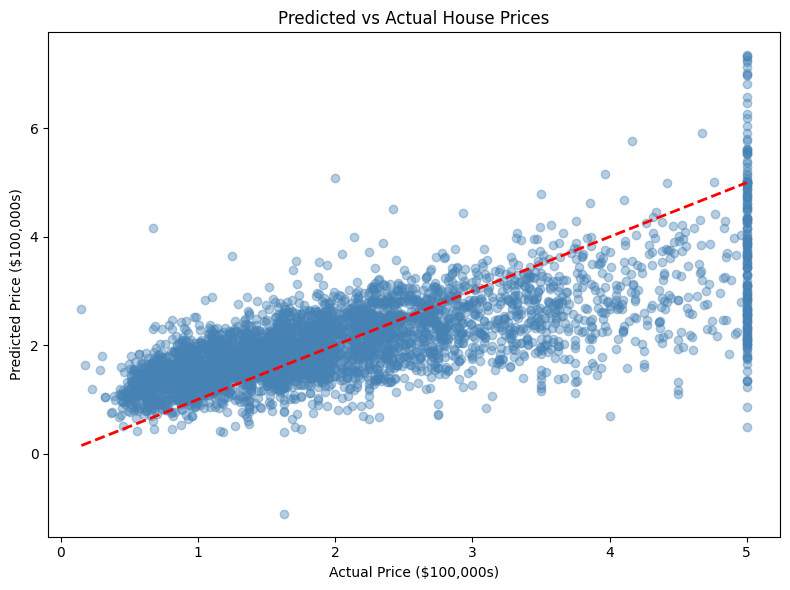

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($100,000s)')
plt.ylabel('Predicted Price ($100,000s)')
plt.title('Predicted vs Actual House Prices')
plt.tight_layout()
plt.show()

## What This R² Score Means

My model's R² score is [X]. In plain terms, this means the model 
can explain about [X*100]% of the reasons why house prices differ 
from one another, based on the four features I gave it — income 
level, house age, room count, and occupancy. The remaining 
percentage is influenced by factors the model doesn't see, like 
exact location, school quality, or renovations. An R² of [X] tells 
us the model is a useful starting point for estimating prices, but 
it shouldn't be treated as a precise valuation tool on its own.